# AQI DATA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Data Loading
city_day = pd.read_csv('data/AQI/city_day.csv', parse_dates=['Date'])
city_hour = pd.read_csv('data/AQI/city_hour.csv', parse_dates=['Datetime'])
station_day = pd.read_csv('data/AQI/station_day.csv',parse_dates=['Date'])
station_hour = pd.read_csv('data/AQI/station_hour.csv',parse_dates=['Datetime'])
stations = pd.read_csv('data/AQI/stations.csv')

/tmp/ipykernel_1465938/2081885417.py:5: DtypeWarning: Columns (0: AQI_Bucket) have mixed types. Specify dtype option on import or set low_memory=False.
  station_hour = pd.read_csv('data/AQI/station_hour.csv',parse_dates=['Datetime'])


## Stations

In [4]:
stations.head()

,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [5]:
stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   StationId    230 non-null    str  
 1   StationName  230 non-null    str  
 2   City         230 non-null    str  
 3   State        230 non-null    str  
 4   Status       133 non-null    str  
dtypes: str(5)
memory usage: 9.1 KB


In [6]:
stations.duplicated().sum()

np.int64(0)

*All columns dtypes are String*

*As we can see there are only null values present in the Status*

*There are not any duplicates rows*

In [7]:
stations.describe()

,StationId,StationName,City,State,Status
count,230,230,230,230,133
unique,230,230,127,21,2
top,AP001,"Secretariat, Amaravati - APPCB",Delhi,Delhi,Active
freq,1,1,38,38,131


In [8]:
stations['StationName'].duplicated().sum()

np.int64(0)

In [9]:
len(stations['StationName'].unique())

230

In [10]:
stations['State'].value_counts()

State
Delhi             38
Haryana           29
Uttar Pradesh     26
Maharashtra       22
Karnataka         20
Madhya Pradesh    16
West Bengal       14
Bihar             10
Rajasthan         10
Kerala             8
Punjab             8
Gujarat            6
Telangana          6
Andhra Pradesh     5
Tamil Nadu         5
Odisha             2
Assam              1
Chandigarh         1
Jharkhand          1
Meghalaya          1
Mizoram            1
Name: count, dtype: int64

In [11]:
len(stations['State'].unique())

21

In [12]:
len(stations['City'].unique())

127

### As per Data Categorical Conversion thinking for StationName, State, City.

*Station Id use for merging*

*StationName has 230 unique value, we can drop it bcz name is not giving any such use full information*

*Station City has 127 unique value, we cannot use ohe due to curse of dimension , we can use target encoding or frequency encoding*

*Station State has 21 unique value , we can use ohe.*


In [13]:
stations['Status'].unique()

<StringArray>
['Active', nan, 'Inactive']
Length: 3, dtype: str

In [14]:
ct = pd.crosstab(stations['State'], stations['Status'])
ct

Status,Active,Inactive
State,,
Andhra Pradesh,2,0
Assam,1,0
Bihar,6,0
Chandigarh,1,0
Delhi,37,1
Gujarat,1,0
Haryana,29,0
Jharkhand,1,0
Karnataka,10,0


Text(0, 0.5, 'Proportion')

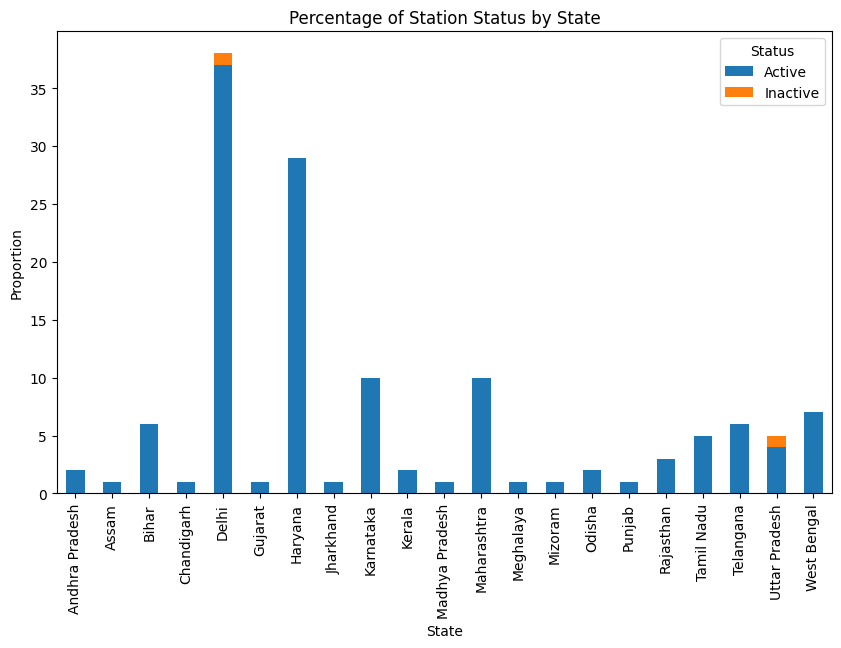

In [15]:


ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Percentage of Station Status by State")
plt.ylabel("Proportion")

### Only Delhi and UP state has Inactiavte Status combined total is 2 only

In [16]:
stations['Status'].value_counts()

Status
Active      131
Inactive      2
Name: count, dtype: int64

### Hypothesis test on State vs Status to check if there is dependencies

H0: Station Status is independent of State


H1: Station Status depends on State



In [17]:
from scipy.stats import chi2_contingency

table = pd.crosstab(stations['State'], stations['Status'])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.866436058222189


#### conclusion: State is not depended on Status

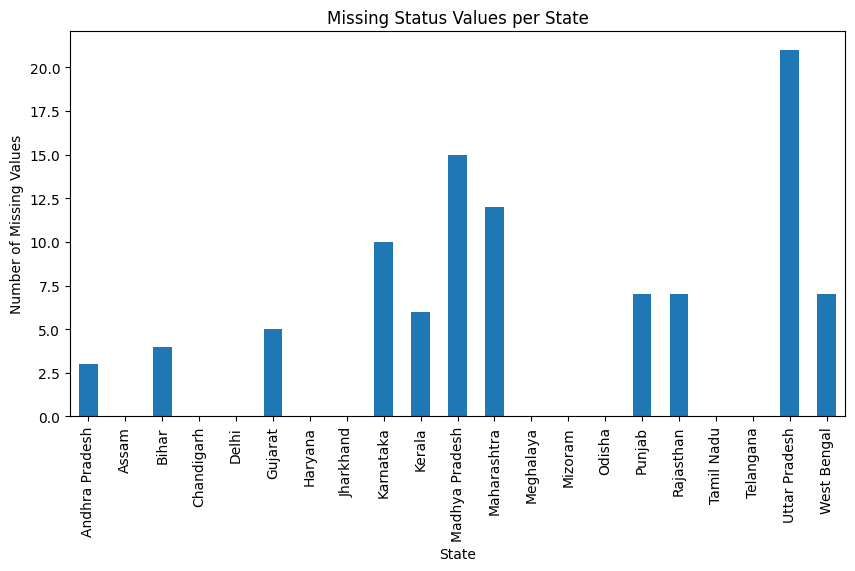

In [18]:
null_counts = stations.groupby('State')['Status'].apply(lambda x: x.isnull().sum())

null_counts.plot(kind='bar', figsize=(10,5))
plt.ylabel("Number of Missing Values")
plt.title("Missing Status Values per State")
plt.show()

In [19]:
stations.groupby('State')['Status'].apply(lambda x: x.isnull().mean()* 100)

State
Andhra Pradesh    60.000000
Assam              0.000000
Bihar             40.000000
Chandigarh         0.000000
Delhi              0.000000
Gujarat           83.333333
Haryana            0.000000
Jharkhand          0.000000
Karnataka         50.000000
Kerala            75.000000
Madhya Pradesh    93.750000
Maharashtra       54.545455
Meghalaya          0.000000
Mizoram            0.000000
Odisha             0.000000
Punjab            87.500000
Rajasthan         70.000000
Tamil Nadu         0.000000
Telangana          0.000000
Uttar Pradesh     80.769231
West Bengal       50.000000
Name: Status, dtype: float64

In [20]:
ct = pd.crosstab(stations['City'],stations['Status'])
ct

Status,Active,Inactive
City,,
Ahmedabad,1,0
Aizawl,1,0
Amaravati,1,0
Ambala,1,0
Amritsar,1,0
Bahadurgarh,1,0
Ballabgarh,1,0
Bengaluru,10,0
Bhiwani,1,0


Text(0, 0.5, 'Proportion')

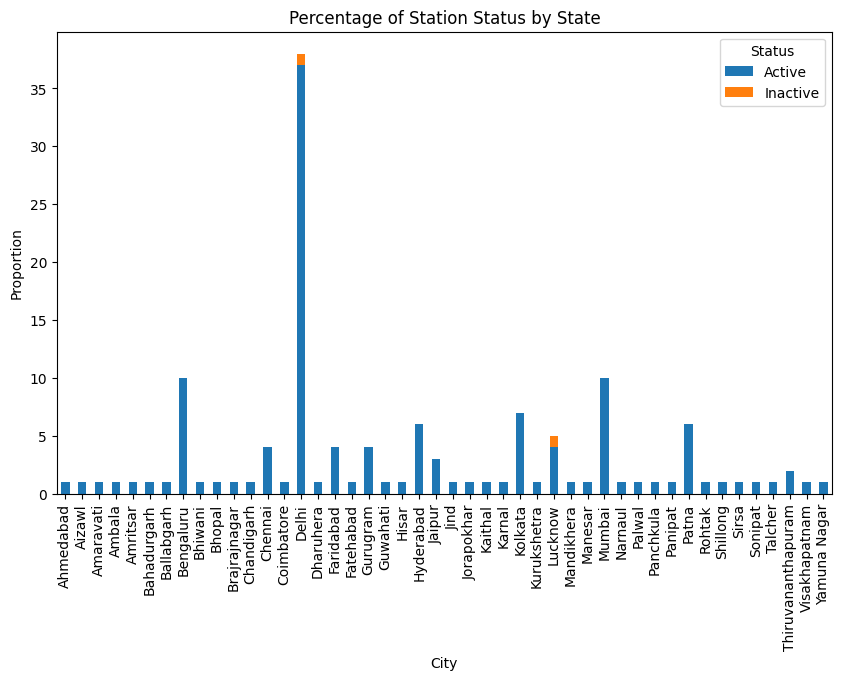

In [21]:
ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Percentage of Station Status by State")
plt.ylabel("Proportion")

### Delhi and Lucknow (from UP) has Inactiave status.

In [22]:
null_counts = stations.groupby('City')['Status'].apply(lambda x: x.isnull().sum())
null_counts = null_counts[null_counts > 0]
null_counts.index

Index(['Agra', 'Ajmer', 'Alwar', 'Ankleshwar', 'Asansol', 'Aurangabad',
       'Bagalkot', 'Baghpat', 'Bathinda', 'Bhiwandi', 'Bulandshahr',
       'Chamarajanagar', 'Chandrapur', 'Chikkaballapur', 'Chikkamagaluru',
       'Damoh', 'Dewas', 'Durgapur', 'Eloor', 'Ernakulam', 'Gandhinagar',
       'Gaya', 'Ghaziabad', 'Gobindgarh', 'Greater Noida', 'Gwalior',
       'Hajipur', 'Haldia', 'Hapur', 'Howrah', 'Hubballi', 'Indore',
       'Jabalpur', 'Jalandhar', 'Jodhpur', 'Kalaburagi', 'Kalyan', 'Kannur',
       'Kanpur', 'Katni', 'Khanna', 'Kochi', 'Kollam', 'Kota', 'Kozhikode',
       'Ludhiana', 'Maihar', 'Mandideep', 'Meerut', 'Moradabad', 'Muzaffarpur',
       'Muzzaffarnagar', 'Mysuru', 'Nagpur', 'Nandesari', 'Nashik',
       'Navi Mumbai', 'Noida', 'Pali', 'Patiala', 'Pithampur', 'Pune',
       'Rajamahendravaram', 'Ramanagara', 'Ratlam', 'Rupnagar', 'Sagar',
       'Satna', 'Siliguri', 'Singrauli', 'Solapur', 'Thane', 'Tirupati',
       'Udaipur', 'Ujjain', 'Vapi', 'Varanasi', 'Vatv

In [23]:
stations.isnull().mean() * 100

StationId       0.000000
StationName     0.000000
City            0.000000
State           0.000000
Status         42.173913
dtype: float64

### I will drop null rows values bcz and IF:

**42% missing**


**not related to city/state**


**not important for AQI prediction**

## Station Hour

In [24]:
station_hour.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN


In [25]:
station_hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 16 columns):
 #   Column      Dtype         
---  ------      -----         
 0   StationId   str           
 1   Datetime    datetime64[us]
 2   PM2.5       float64       
 3   PM10        float64       
 4   NO          float64       
 5   NO2         float64       
 6   NOx         float64       
 7   NH3         float64       
 8   CO          float64       
 9   SO2         float64       
 10  O3          float64       
 11  Benzene     float64       
 12  Toluene     float64       
 13  Xylene      float64       
 14  AQI         float64       
 15  AQI_Bucket  str           
dtypes: datetime64[us](1), float64(13), str(2)
memory usage: 316.1 MB


In [26]:
station_hour['AQI_Bucket'].unique()

<StringArray>
[nan, 'Moderate', 'Poor', 'Very Poor', 'Satisfactory', 'Good', 'Severe']
Length: 7, dtype: str

*As AQI bucket is str, and contain 6 unique value which also has order between them , we can use ordinal encoding*

In [27]:
station_hour.duplicated().sum()

np.int64(0)

*Not Any Duplicates Columns*

In [28]:
station_hour.describe()

,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,2589083,1.941394e+06,1.469831e+06,2.035372e+06,2.060110e+06,2.098275e+06,1.352465e+06,2.089781e+06,1.846346e+06,1.863110e+06,1.727504e+06,1.546717e+06,513979.000000,2.018893e+06
mean,2018-08-17 09:52:35.777856,8.086481e+01,1.584839e+02,2.278825e+01,3.523689e+01,4.055115e+01,2.870856e+01,1.502366e+00,1.211602e+01,3.806408e+01,3.305493e+00,1.490266e+01,2.448881,1.801730e+02
min,2015-01-01 01:00:00,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,0.000000e+00,0.000000,5.000000e+00
25%,2017-10-13 20:00:00,2.816000e+01,6.400000e+01,3.050000e+00,1.310000e+01,1.135000e+01,1.123000e+01,4.100000e-01,4.250000e+00,1.102000e+01,8.000000e-02,3.400000e-01,0.000000,8.400000e+01
50%,2018-12-02 06:00:00,5.259000e+01,1.162500e+02,7.150000e+00,2.479000e+01,2.286000e+01,2.235000e+01,8.000000e-01,8.250000e+00,2.475000e+01,9.600000e-01,3.400000e+00,0.200000,1.310000e+02
75%,2019-10-15 06:00:00,9.774000e+01,2.040000e+02,1.858000e+01,4.548000e+01,4.570000e+01,3.778000e+01,1.380000e+00,1.453000e+01,4.953000e+01,3.230000e+00,1.510000e+01,1.830000,2.590000e+02
max,2020-07-01 00:00:00,1.000000e+03,1.000000e+03,5.000000e+02,4.999900e+02,5.000000e+02,4.999700e+02,4.985700e+02,1.999600e+02,9.970000e+02,4.980700e+02,4.999900e+02,499.990000,3.133000e+03
std,NaN,8.947618e+01,1.397883e+02,4.846146e+01,3.497508e+01,5.590894e+01,2.753244e+01,6.292445e+00,1.467385e+01,4.710653e+01,1.214053e+01,3.329729e+01,8.973470,1.404095e+02


*We can conclude the facts from stats tables, there are so many null values present (like in Xylene, we can drop if not much imp). mean > medain in most of cols , so right skewed data.Also there are high max values far far away from 75% so there are extreme values present , we can remove or handle the outlier's. There are also 0 as a min value , we can check 0 is actual measurement or not.Unrealistic AQI Value.*



In [29]:
station_hour.isnull().mean().mean() * 100

np.float64(28.15787481513725)

*28% Null values*

In [30]:
print("NUll Values present in eacxh columns:")
for col in station_hour.columns:
    print(f"{col} : ", station_hour[col].isnull().sum(), "  Percentage : ", station_hour[col].isnull().mean() * 100)
    

NUll Values present in eacxh columns:
StationId :  0   Percentage :  0.0
Datetime :  0   Percentage :  0.0
PM2.5 :  647689   Percentage :  25.01615436816819
PM10 :  1119252   Percentage :  43.22966857377689
NO :  553711   Percentage :  21.386375021581
NO2 :  528973   Percentage :  20.430901597206425
NOx :  490808   Percentage :  18.95682757176962
NH3 :  1236618   Percentage :  47.762779331523944
CO :  499302   Percentage :  19.28489739417392
SO2 :  742737   Percentage :  28.68726108819223
O3 :  725973   Percentage :  28.039773155205914
Benzene :  861579   Percentage :  33.277380447054036
Toluene :  1042366   Percentage :  40.26004573820152
Xylene :  2075104   Percentage :  80.14822236289837
AQI :  570190   Percentage :  22.022855196221983
AQI_Bucket :  570190   Percentage :  22.022855196221983


*Xylene contain 80% missing, mostly we can think of dropping it otherwise its depend on also if contain any relationship with other column or target feature*

*columns around 30% can be fill with Imputation Techniques.*


| Column     | Missing % | Recommended Action                       |
| ---------- | --------- | ---------------------------------------- |
| PM2.5      | 25%       | interpolate / station median             |
| PM10       | 43%       | interpolate                              |
| NO         | 21%       | interpolate                              |
| NO2        | 20%       | interpolate                              |
| NOx        | 19%       | interpolate                              |
| NH3        | 48%       | evaluate carefully                       |
| CO         | 19%       | interpolate                              |
| SO2        | 28%       | interpolate                              |
| O3         | 28%       | interpolate                              |
| Benzene    | 33%       | interpolate / median                     |
| Toluene    | 40%       | evaluate                                 |
| Xylene     | 80%       | drop column                              |
| AQI        | 22%       | investigate relationship with pollutants |
| AQI_Bucket | 22%       | derive from AQI                          |


In [31]:
station_hour['AQI_Bucket'].value_counts()

AQI_Bucket
Moderate        675008
Satisfactory    530164
Very Poor       301150
Poor            239990
Good            152113
Severe          120468
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='AQI_Bucket'>

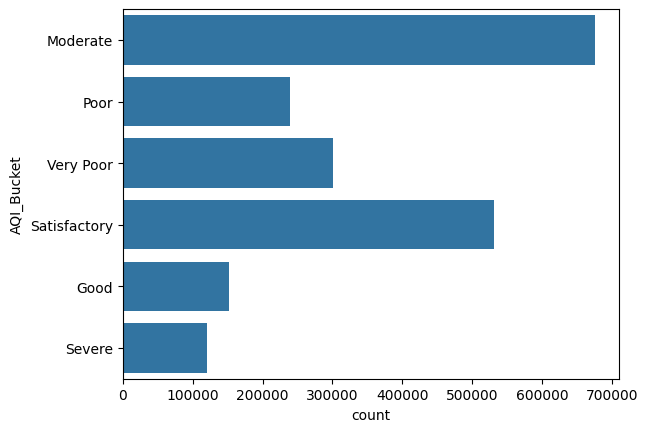

In [32]:
sns.countplot(station_hour['AQI_Bucket'])

*We can see there are imbalance category : Good and Serve. Later we can use imbalance technique to balance the dataset.*

<Axes: xlabel='AQI', ylabel='Count'>

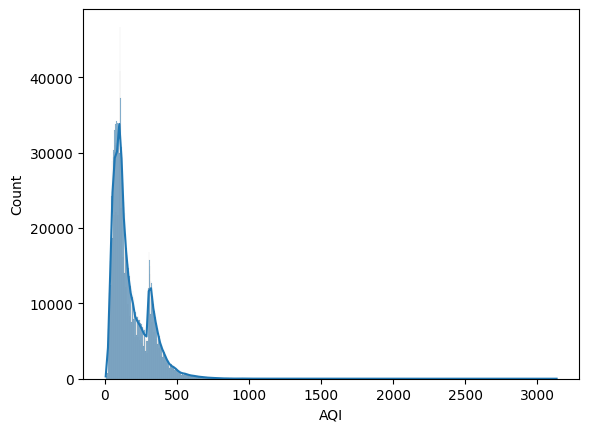

In [33]:
sns.histplot(station_hour['AQI'],kde=True)

*Its Right SKewed, we can log transform the data for better model accuracy and learning* 

*Extreme Values are present which is so unrealistic we can remove by IQR.*

<Axes: xlabel='AQI_Bucket', ylabel='AQI'>

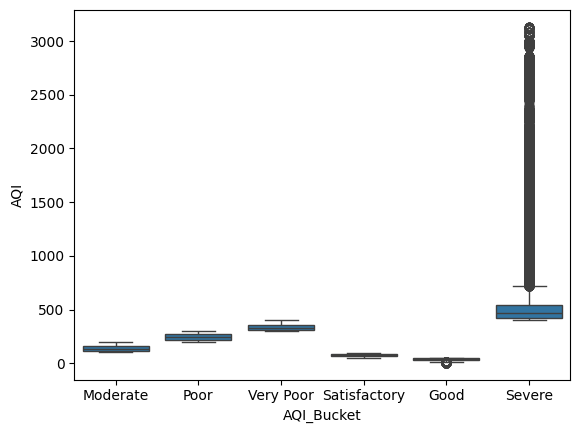

In [34]:
sns.boxplot(x='AQI_Bucket', y='AQI', data=station_hour)

In [35]:
station_hour[station_hour['AQI'].isnull()].describe()

,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,570190,61288.000000,48024.000000,140977.000000,140276.000000,236822.000000,67833.000000,241722.000000,122301.000000,118503.000000,219319.000000,198511.000000,80567.000000,0.0
mean,2017-08-12 03:09:41.932337,83.957297,148.564463,21.395829,36.756960,25.107079,30.468623,1.301027,11.615461,34.982376,1.799498,7.044946,0.562326,NaN
min,2015-01-01 01:00:00,0.010000,0.010000,0.010000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,NaN
25%,2016-08-04 09:00:00,25.500000,57.640000,3.950000,12.550000,0.000000,8.000000,0.000000,3.730000,12.550000,0.000000,0.000000,0.000000,NaN
50%,2017-06-27 21:00:00,50.245000,109.855000,8.620000,24.610000,10.750000,18.150000,0.000000,7.000000,25.050000,0.000000,0.000000,0.000000,NaN
75%,2018-07-19 11:00:00,99.992500,192.272500,22.930000,46.582500,28.940000,36.980000,0.930000,13.070000,44.300000,1.670000,3.610000,0.000000,NaN
max,2020-07-01 00:00:00,1000.000000,1000.000000,499.990000,499.990000,499.990000,497.380000,388.040000,199.950000,988.170000,498.070000,499.800000,223.420000,NaN
std,NaN,104.931188,135.842153,42.596929,39.857783,46.133243,41.172548,5.671210,16.543514,41.665621,7.927160,23.002899,3.187044,NaN


*There are columns which are direclty affected if AQI is not present*

*AQI cannot be calculated because the required pollutant measurements are missing.*

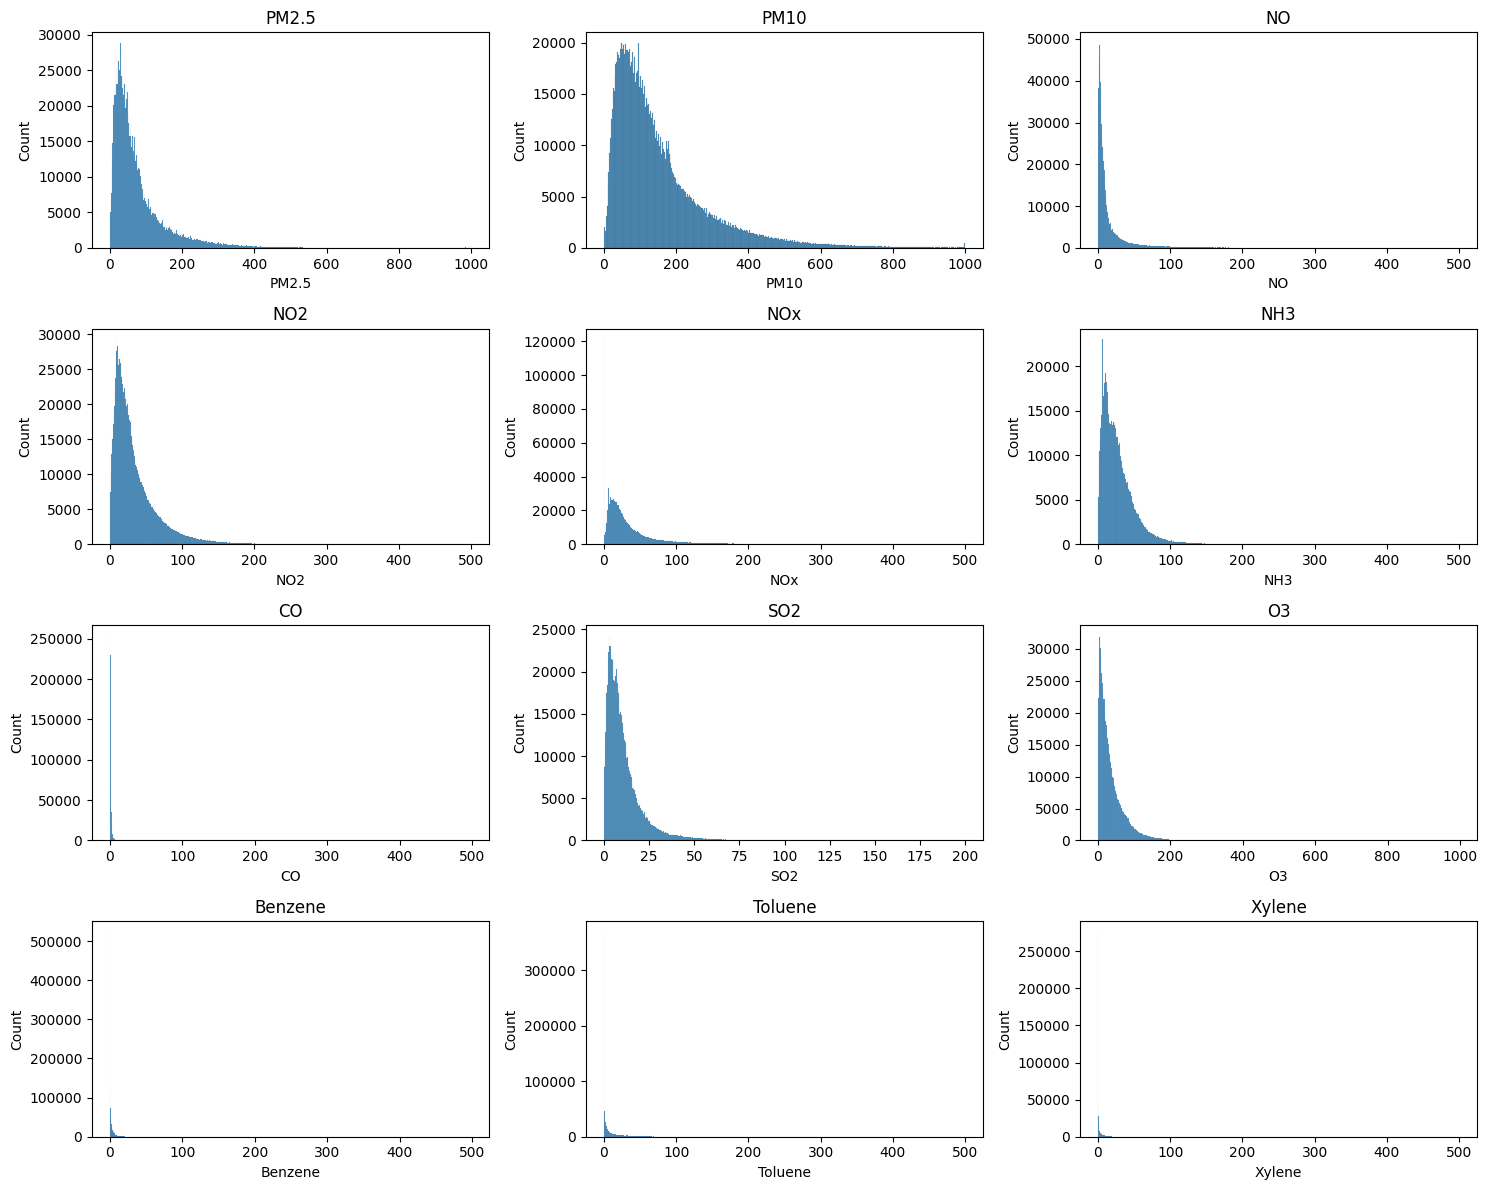

In [12]:
cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

fig, ax = plt.subplots(4,3, figsize=(15,12))

for i, col in enumerate(cols):
    
    row = i // 3
    col_pos = i % 3
    
    sns.histplot(station_hour[col], ax=ax[row, col_pos])
    ax[row, col_pos].set_title(col)

plt.tight_layout()
plt.show()




*Rigth skewed Data is present allover the cols, and CO contain mostly same values and Benzene, Toluene , Xylene has many null values*

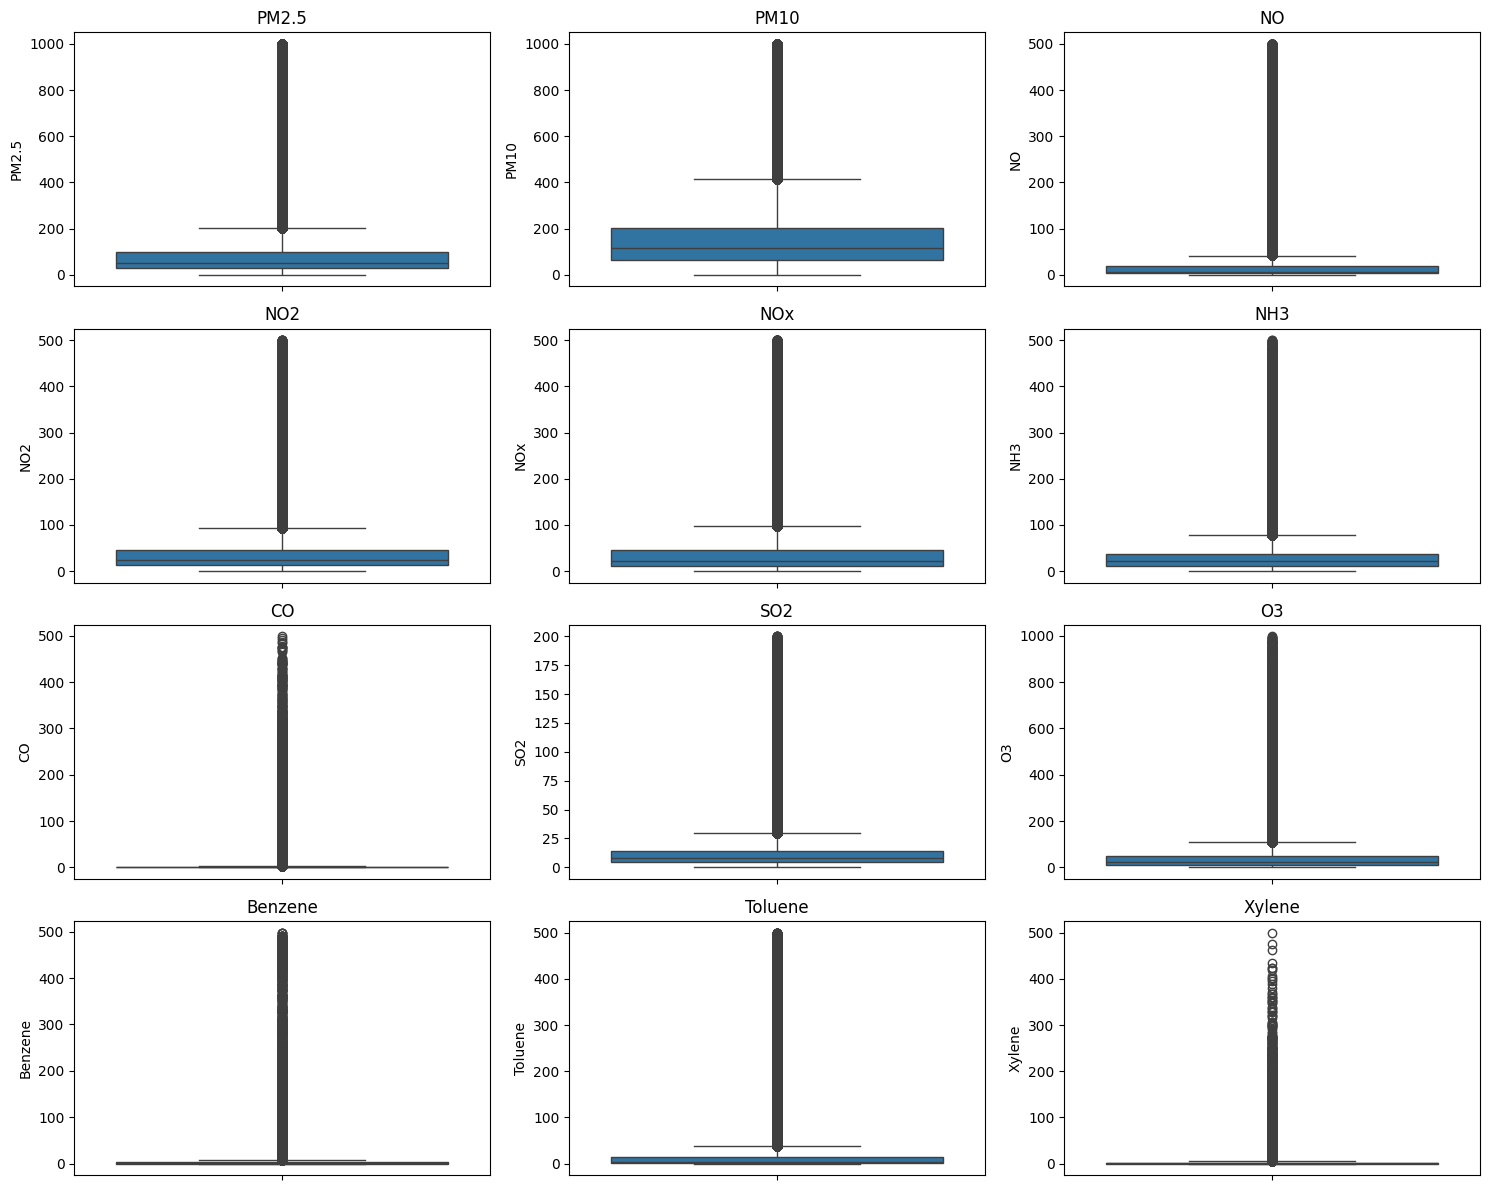

In [37]:

fig, ax = plt.subplots(4,3, figsize=(15,12))

for i, col in enumerate(cols):
    
    row = i // 3
    col_pos = i % 3
    
    sns.boxplot(station_hour[col], ax=ax[row, col_pos])
    ax[row, col_pos].set_title(col)

plt.tight_layout()
plt.show()



*Contain many outlier, but some outier help full to describe the poluution increases at time or daay or season.. but some are extreme which are unrealistic*

In [38]:
for col in cols:
    print(col, (station_hour[col]==0).sum())

PM2.5 0
PM10 0
NO 0
NO2 0
NOx 117924
NH3 0
CO 181502
SO2 0
O3 0
Benzene 392342
Toluene 312987
Xylene 208359


*Certain pollutants such as Benzene and Toluene show a high number of zero values, which may represent either true absence or measurement thresholds.*

Text(0.5, 1.0, 'Missing Percentage per Pollutant')

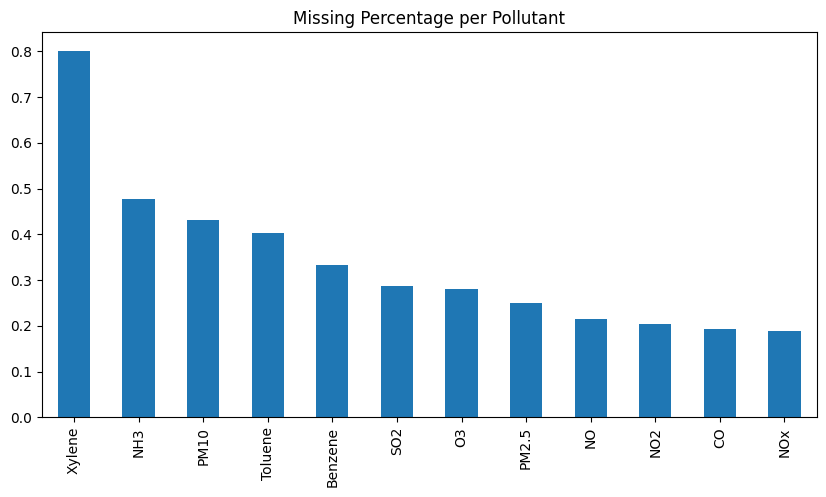

In [39]:
missing = station_hour[cols].isnull().mean().sort_values(ascending=False)

missing.plot(kind='bar', figsize=(10,5))
plt.title("Missing Percentage per Pollutant")

In [40]:
station_hour[cols].skew().sort_values(ascending=False)

CO         33.508087
Benzene    21.345900
Xylene     16.347887
Toluene     5.839818
O3          5.474361
SO2         4.786037
NO          4.765423
NH3         4.028852
NOx         3.603130
PM2.5       3.344412
NO2         3.063309
PM10        2.047849
dtype: float64

*High positive skewness across pollutants suggests the presence of occasional extreme pollution levels compared to normal value.*

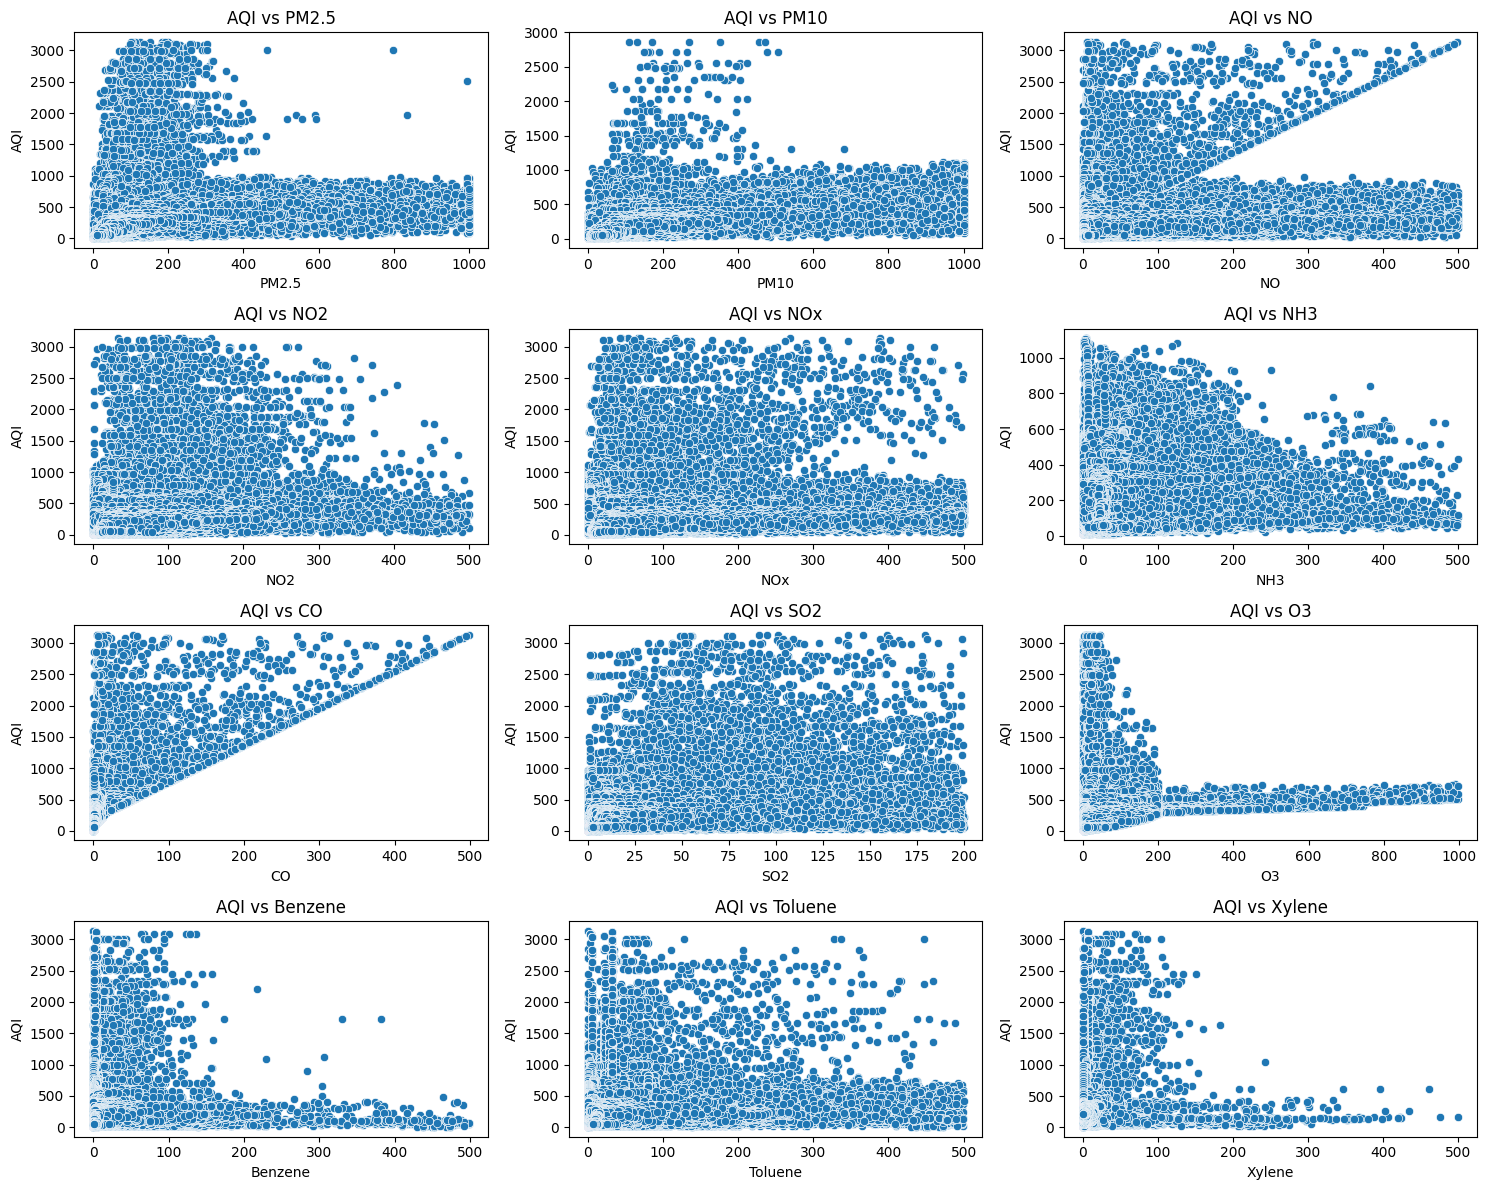

In [41]:
# pollutants vs AQI

fig, ax = plt.subplots(4,3, figsize=(15,12))
for i, col in enumerate(cols):
    
    row = i // 3
    col_pos = i % 3
    
    sns.scatterplot(x=col, y='AQI', data=station_hour, ax=ax[row, col_pos])
    ax[row, col_pos].set_title(f"AQI vs {col}")

plt.tight_layout()
plt.show()

*Pm2.5 and PM10 show the strongest relationship in between with AQI values, while NH3, SO2, O3 has week relationship*

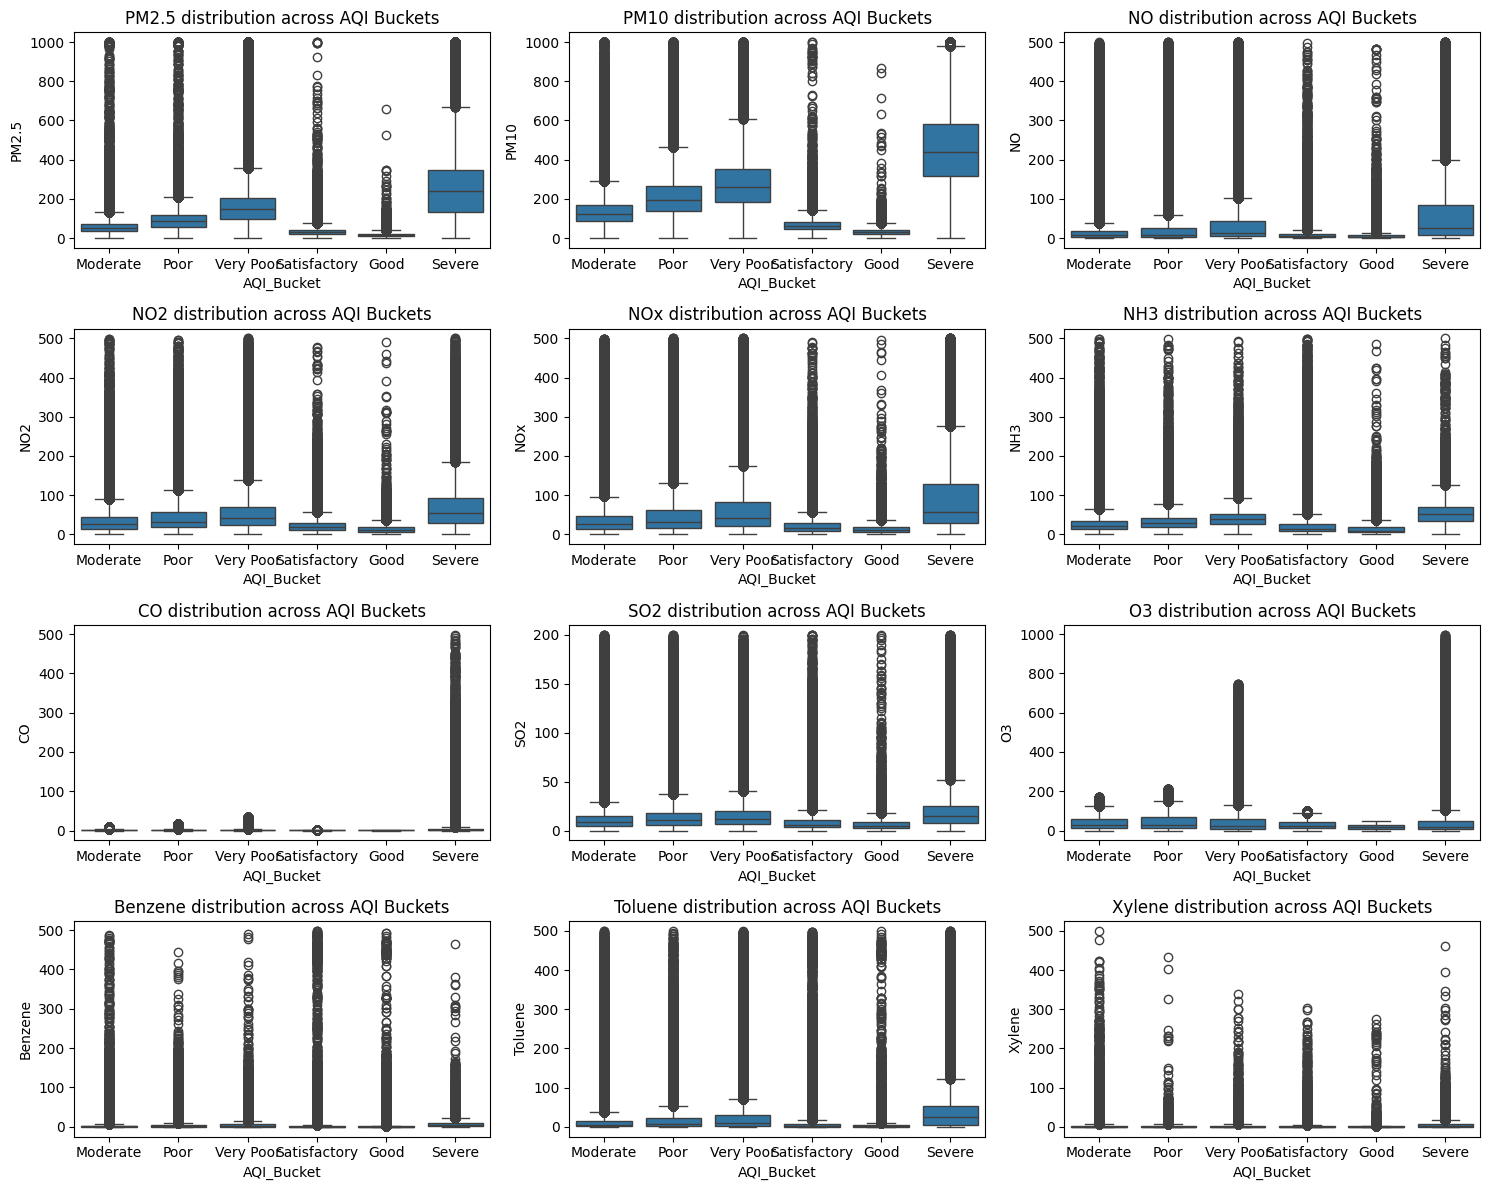

In [44]:
fig , ax = plt.subplots(4,3, figsize=(15,12))

for i, col in enumerate(cols):
    row = i // 3
    col_pos = i % 3
    sns.boxplot(x='AQI_Bucket', y=col, data=station_hour, ax=ax[row, col_pos])
    ax[row, col_pos].set_title(f"{col} distribution across AQI Buckets")

plt.tight_layout()
plt.show()

*PM2.5 and PM10 has the most consistent upward trend across AQI buckets, with significantly higher median and spread in the Severe and Very Poor categories, suggesting that particulate matter is a major driver of AQI levels. Pollutants such as NO2, NOx, and CO also show moderate increases with higher AQI categories, though with larger variability, while SO2, Benzene, Toluene, and Xylene display weaker or less consistent patterns*

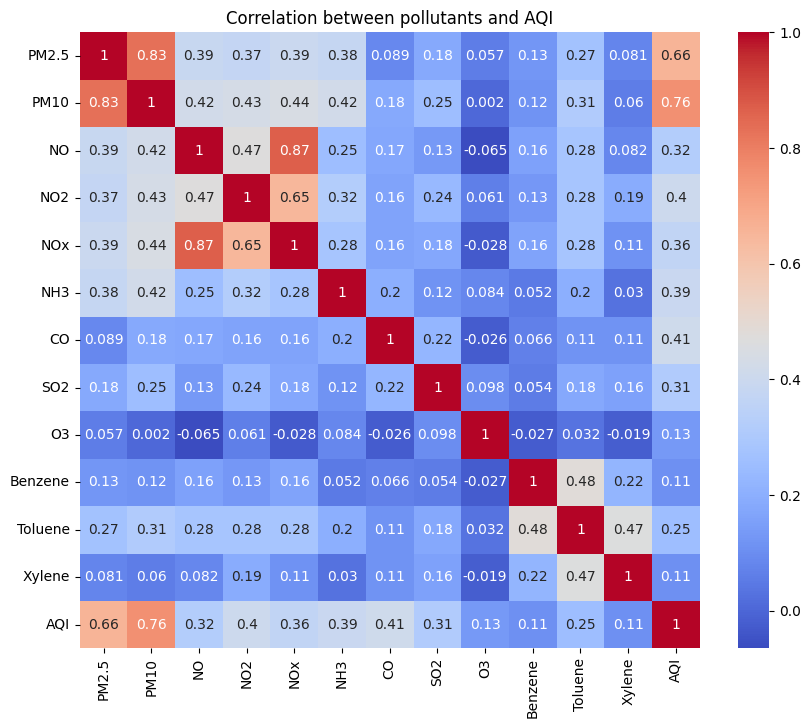

In [10]:
plt.figure(figsize=(10,8))

corr = station_hour.drop(columns=['StationId','Datetime','AQI_Bucket']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation between pollutants and AQI")
plt.show()

*PM2.5 and PM10 highly correlated with each other and also with AQI.while O3, benzene, Toluene, and Xylene is very weak correlated with AQI.Also No and Nox is highly correalted*

In [25]:
station_hour['year'] = station_hour['Datetime'].dt.year
station_hour['month'] = station_hour['Datetime'].dt.month
station_hour['day'] = station_hour['Datetime'].dt.day
station_hour['hour'] = station_hour['Datetime'].dt.hour
station_hour['day_of_week'] = station_hour['Datetime'].dt.dayofweek
station_hour['week_type'] = station_hour['day_of_week'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

<Axes: xlabel='hour'>

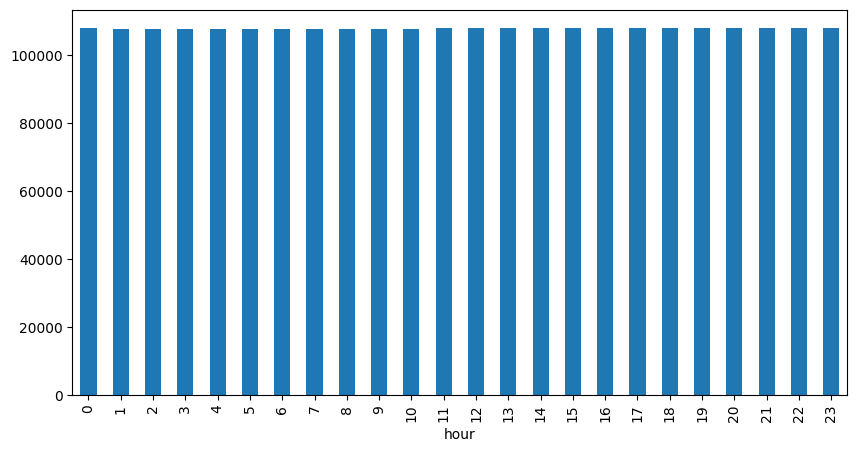

In [17]:
station_hour['hour'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))

Text(0.5, 1.0, 'Average AQI by Hour')

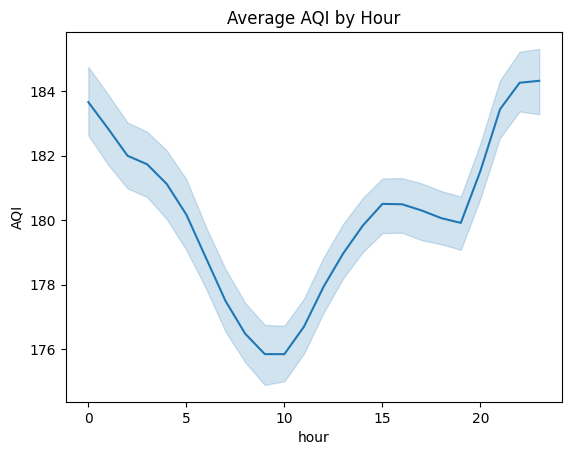

In [15]:
sns.lineplot(x='hour', y='AQI', data=station_hour)
plt.title("Average AQI by Hour")

*As per graph , we can conclude that mid night has decresing flow of AQI , and after 10 am AQI level increases as day started till night*

Text(0.5, 1.0, 'AQI distribution across months')

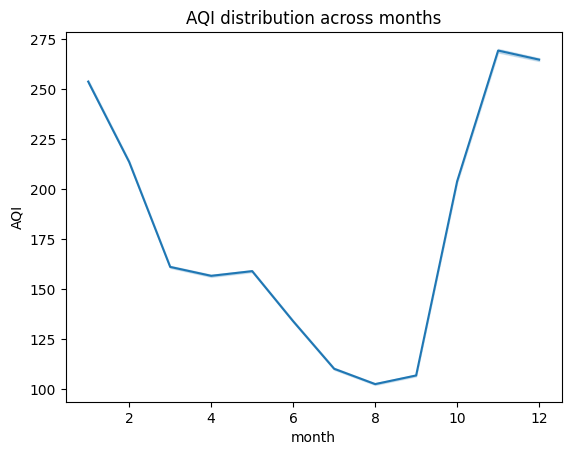

In [19]:
sns.lineplot(x='month', y='AQI', data=station_hour)
plt.title("AQI distribution across months")

*Pattern says in winter has the high AQI , which is True and during summer and monsson is low*

Text(0.5, 1.0, 'AQI distribution across days of week')

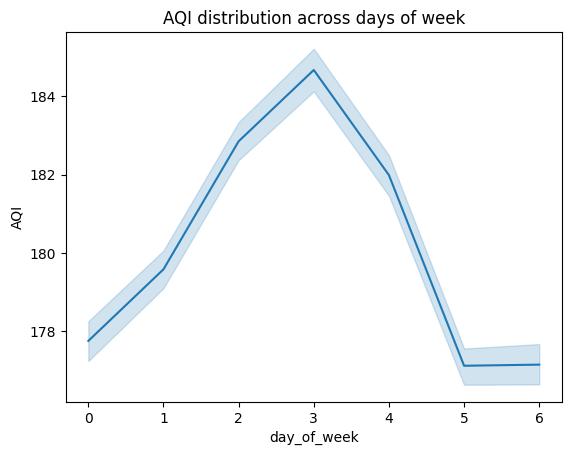

In [21]:
sns.lineplot(x='day_of_week', y='AQI', data=station_hour)
plt.title("AQI distribution across days of week")

*Tuesday, Wednesday and Thrusday reeahed the AQI peak , during these days all people goes to work as we know*

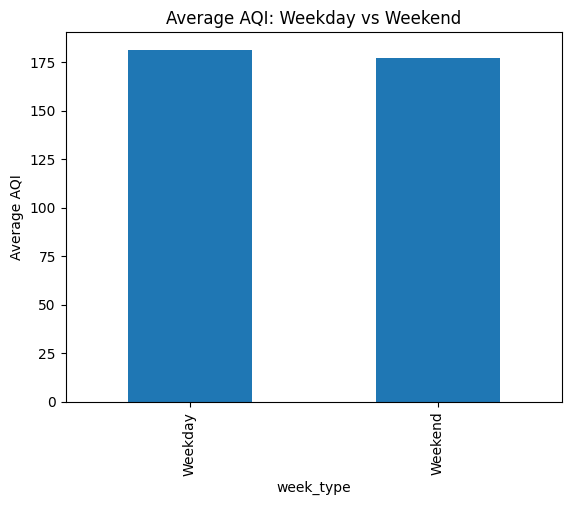

In [26]:
station_hour.groupby('week_type')['AQI'].mean().plot(kind='bar')

plt.title("Average AQI: Weekday vs Weekend")
plt.ylabel("Average AQI")
plt.show()

*Avg mean is same , if there is weekend or not*

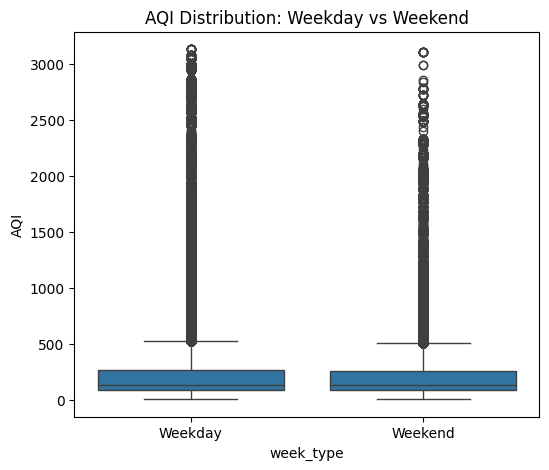

In [27]:
plt.figure(figsize=(6,5))
sns.boxplot(x='week_type', y='AQI', data=station_hour)

plt.title("AQI Distribution: Weekday vs Weekend")
plt.show()

<Axes: xlabel='month', ylabel='count'>

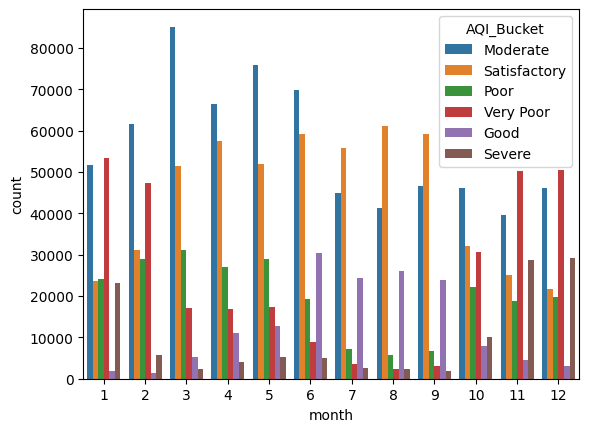

In [28]:
sns.countplot(x='month', hue='AQI_Bucket', data=station_hour)

*Mostly AQI is Moderate during all months, only in winter the AQI is very poor*

Text(0.5, 1.0, 'AQI Heatmap (Hour vs Month)')

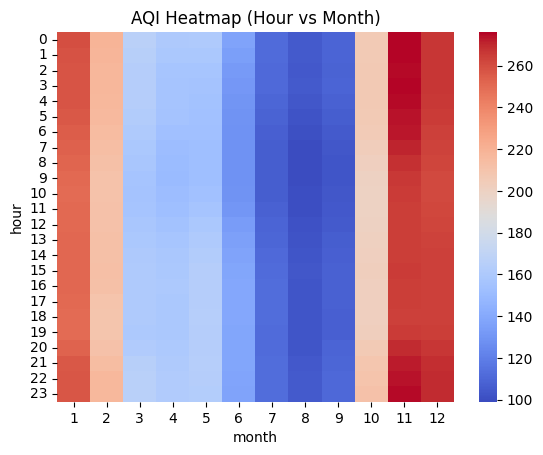

In [ ]:
pivot = station_hour.pivot_table(values='AQI', index='hour', columns='month', aggfunc='mean')
sns.heatmap(pivot, cmap='coolwarm')
plt.title("AQI Heatmap (Hour vs Month)")

*7,8,9 no. of months which is monsoon season, all day AQI is nearly low.*

<Axes: xlabel='year', ylabel='AQI'>

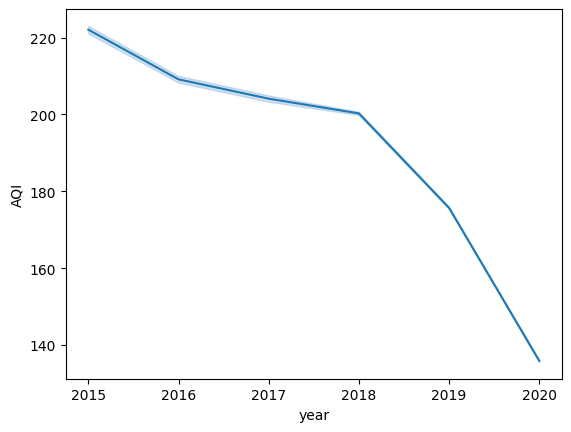

In [30]:
sns.lineplot(x='year', y='AQI', data=station_hour)

*As we seen AQI is been decreasing year by year, which is may be true or may not be, can be happend due to missing value or rising on corona due to lockdown AQI decreased*

In [118]:
merged_df = pd.merge(station_hour, stations, on='StationId',how='left')
merged_df.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,month,day,hour,day_of_week,is_weekend,week_type,StationName,City,State,Status
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,...,11,24,17,4,0,Weekday,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,...,11,24,18,4,0,Weekday,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,...,11,24,19,4,0,Weekday,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,...,11,24,20,4,0,Weekday,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,...,11,24,21,4,0,Weekday,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


*Lets check this status , is depended on AQI or not*

<Axes: xlabel='Status'>

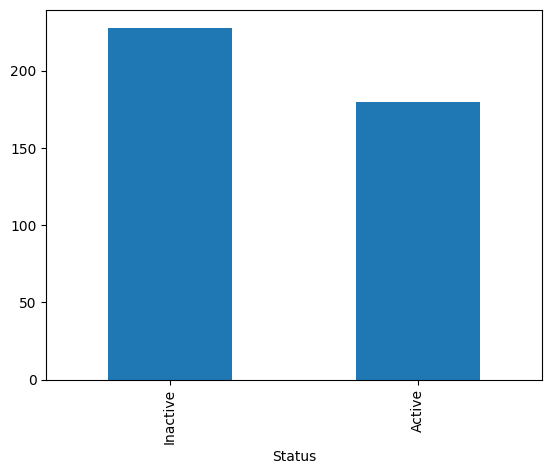

In [45]:
merged_df.groupby('Status')['AQI'].mean().sort_values(ascending=False).plot.bar()

*Mean of Inactive Status Values are higher than Active, how can be possible? may be values are wrong or human filled*

In [42]:
len(merged_df.groupby('Status')['AQI'].value_counts()['Inactive'])

656

In [44]:
len(merged_df.groupby('Status')['AQI'].value_counts()['Active'])

1601

- Ho : Status is not relation with AQI
- H1 :  STatus is depeneded on AQI



In [53]:
from scipy.stats import f_oneway

df = merged_df[['Status','AQI']].dropna()

groups = df.groupby('Status')['AQI'].apply(list)

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 3391.1271517042383
P-value: 0.0


*We need to reject the null hypothesis, p value is smaller than 0.05 , means values of AQI is depending on station status*

In [78]:
merged_df[merged_df['Status'] == 'Inactive'].isnull().mean().mean() * 100

np.float64(24.146987678657545)

In [79]:
merged_df[merged_df['Status'] == 'Active'].isnull().mean().mean() * 100

np.float64(16.593090668360556)

*Incative stations has most null vales and highly mean than actiave status AQI values , it can be added by human or machine error*

<Axes: xlabel='State'>

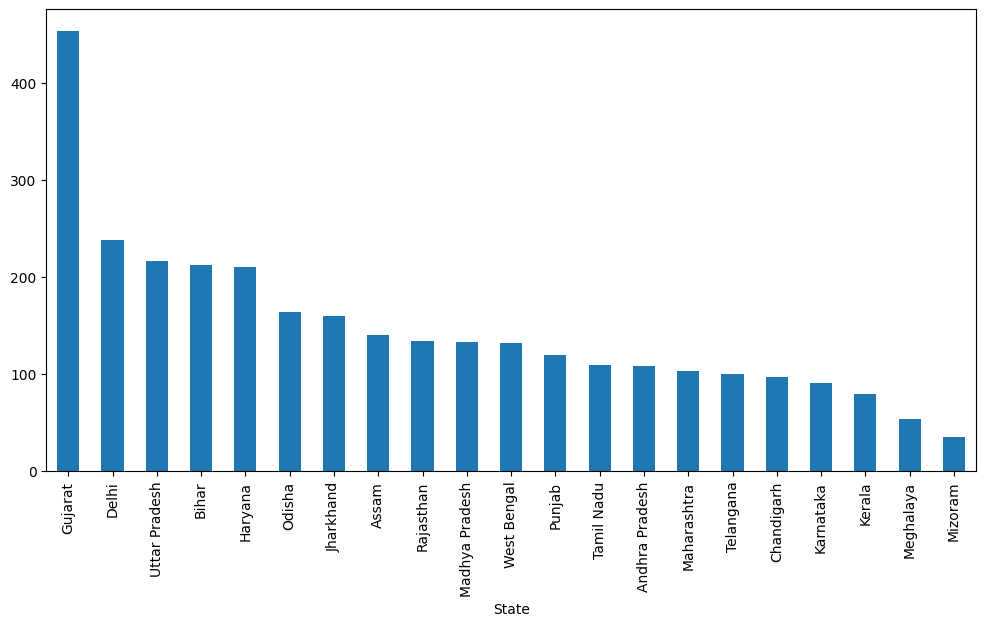

In [ ]:
merged_df.groupby('State')['AQI'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12,6))

*Gujarat is most polluted state?*

In [65]:
stations['City'].unique()

<StringArray>
[        'Amaravati', 'Rajamahendravaram',          'Tirupati',
        'Vijayawada',     'Visakhapatnam',          'Guwahati',
              'Gaya',           'Hajipur',       'Muzaffarpur',
             'Patna',
 ...
         'Moradabad',    'Muzzaffarnagar',             'Noida',
          'Varanasi',           'Asansol',          'Durgapur',
            'Haldia',            'Howrah',           'Kolkata',
          'Siliguri']
Length: 127, dtype: str

In [66]:
stations['StationId'].nunique()

230

In [67]:
station_hour['StationId'].nunique()

110

In [63]:
merged_df['City'].unique()

<StringArray>
[         'Amaravati',      'Visakhapatnam',           'Guwahati',
              'Patna',         'Chandigarh',              'Delhi',
          'Ahmedabad',           'Gurugram',         'Jorapokhar',
          'Bengaluru',          'Ernakulam',              'Kochi',
 'Thiruvananthapuram',             'Mumbai',           'Shillong',
             'Bhopal',             'Aizawl',       'Brajrajnagar',
            'Talcher',           'Amritsar',             'Jaipur',
          'Hyderabad',            'Chennai',         'Coimbatore',
            'Lucknow',            'Kolkata']
Length: 26, dtype: str

*After Joining, 101 city data was not in station_hour data*

Text(0.5, 1.0, 'Average AQI by State')

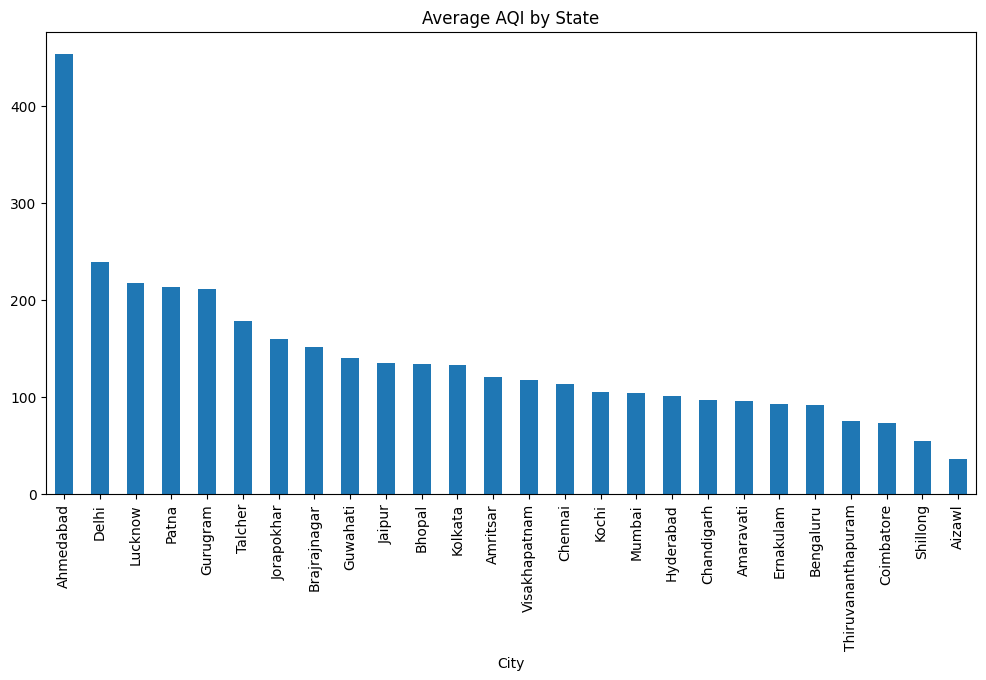

In [56]:
merged_df.groupby('City')['AQI'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("Average AQI by State")

*Ahmedabad has the highest AQI*

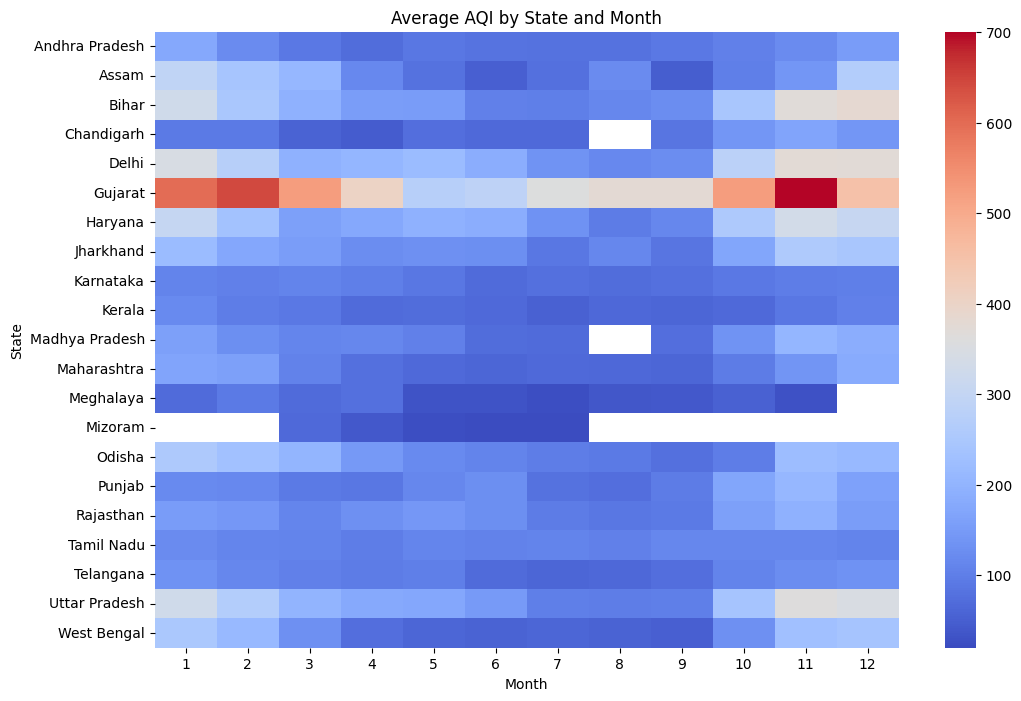

In [75]:
pivot = merged_df.groupby(['State','month'])['AQI'].mean().unstack()

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Average AQI by State and Month")
plt.xlabel("Month")
plt.ylabel("State")
plt.show()

In [103]:
station_hour.head(50)

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Xylene,AQI,AQI_Bucket,year,month,day,hour,day_of_week,is_weekend,week_type
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.10,11.85,...,0.10,NaN,NaN,2017,11,24,17,4,0,Weekday
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.10,13.17,...,0.15,NaN,NaN,2017,11,24,18,4,0,Weekday
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.10,12.08,...,0.18,NaN,NaN,2017,11,24,19,4,0,Weekday
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.10,10.47,...,0.10,NaN,NaN,2017,11,24,20,4,0,Weekday
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.10,9.12,...,0.08,NaN,NaN,2017,11,24,21,4,0,Weekday
5,AP001,2017-11-24 22:00:00,69.25,108.25,0.70,18.47,10.38,13.80,0.10,9.25,...,0.00,NaN,NaN,2017,11,24,22,4,0,Weekday
6,AP001,2017-11-24 23:00:00,67.50,111.50,1.05,12.15,7.30,17.65,0.10,9.40,...,0.10,NaN,NaN,2017,11,24,23,4,0,Weekday
7,AP001,2017-11-25 00:00:00,68.00,111.00,1.25,14.12,8.50,20.28,0.10,8.90,...,0.05,NaN,NaN,2017,11,25,0,5,1,Weekend
8,AP001,2017-11-25 01:00:00,73.00,102.00,0.30,14.30,7.90,11.50,0.30,11.80,...,0.00,NaN,NaN,2017,11,25,1,5,1,Weekend
9,AP001,2017-11-25 02:00:00,81.00,123.00,0.80,24.85,13.88,10.28,0.10,11.62,...,0.10,NaN,NaN,2017,11,25,2,5,1,Weekend


In [111]:
cols_to_drop = ['week_type','AQI_Bucket','StationId',]

station_hour.drop(columns=cols_to_drop).tail(25).mean()

Datetime       2020-06-30 12:00:00
PM2.5                      15.8464
PM10                       39.1908
NO                        7.574615
NO2                      28.621538
NOx                      36.194615
NH3                      29.104615
CO                          0.6896
SO2                          5.754
O3                         28.9808
Benzene                      1.834
Toluene                     8.3588
Xylene                         NaN
AQI                          56.64
year                        2020.0
month                         6.04
day                          28.84
hour                         11.04
day_of_week                   1.04
is_weekend                     0.0
dtype: object

In [112]:
station_day.tail(2)

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
108033,WB013,2020-06-30,16.07,39.3,7.56,29.13,36.69,29.26,0.69,5.88,29.64,1.86,8.40,NaN,57.0,Satisfactory
108034,WB013,2020-07-01,10.50,36.5,7.78,22.50,30.25,27.23,0.58,2.80,13.10,1.31,7.39,NaN,59.0,Satisfactory


*As we seen the avg out of dated 2020-06-30 is almost same , so we are having same information mean values, in station day , city hour, city day from station hour*

In [113]:
city_hour['City'].unique()

<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str

*After merge station hour and stations, we are having only 26 city, as here in city hour is taken that only*

<Axes: xlabel='City'>

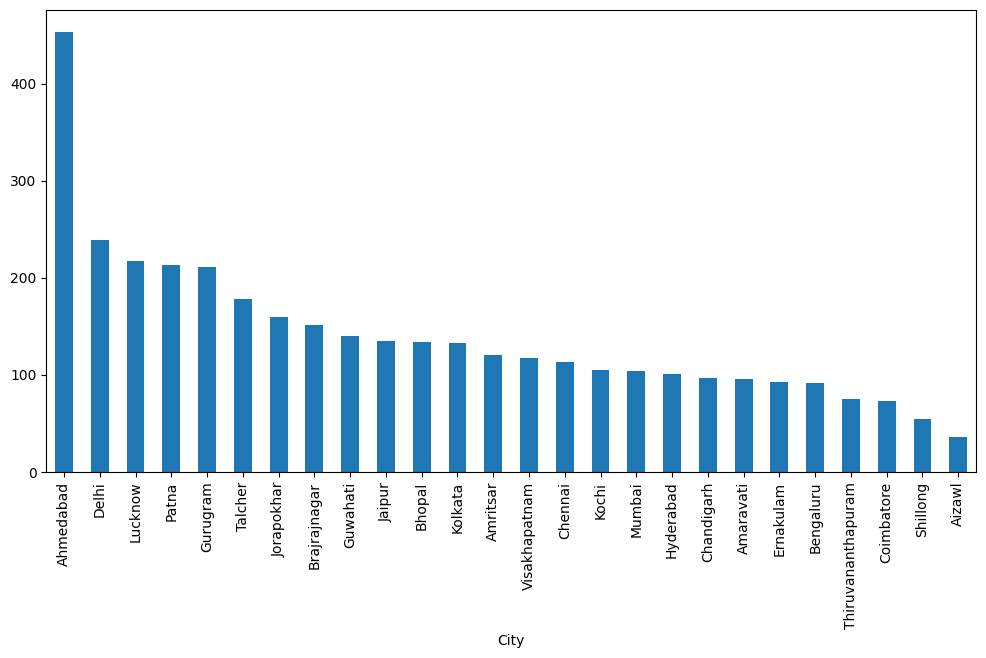

In [129]:
merged_df.groupby('City')['AQI'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12,6))

<Axes: xlabel='City'>

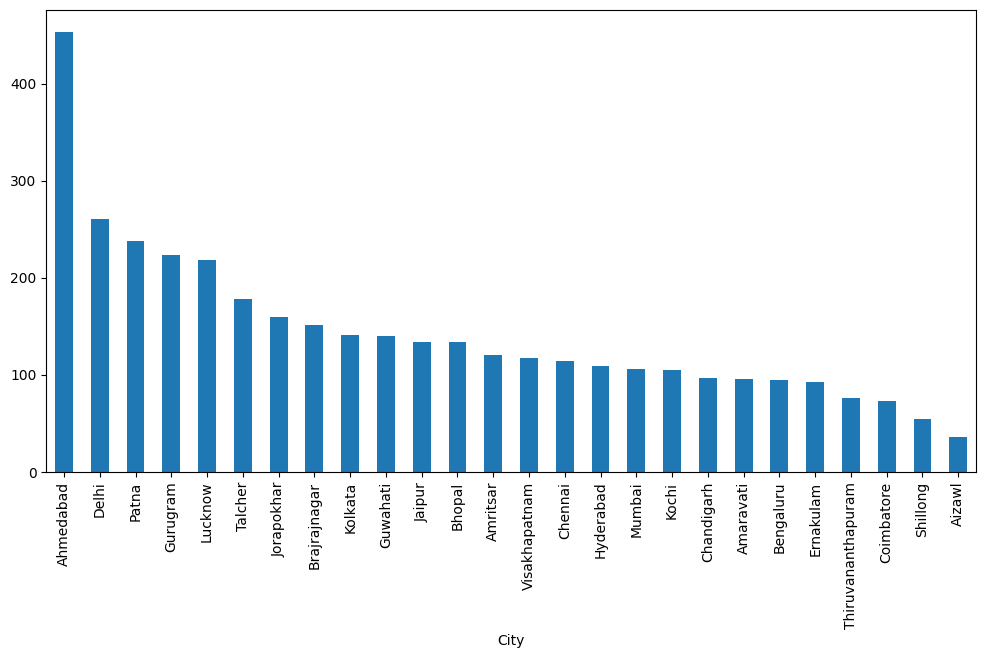

In [128]:
city_hour.groupby('City')['AQI'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12,6))

*Hence Proved , City hour is derived from station hour*

In [137]:
city_hour.drop(columns=['AQI_Bucket','City']).tail(25).mean()

Datetime    2020-06-30 12:00:00
PM2.5                     16.57
PM10                      50.61
NO                       3.9036
NO2                     29.1672
NOx                     18.6096
NH3                      9.8384
CO                       0.5232
SO2                    9.502609
O3                       27.848
Benzene                     0.0
Toluene                     0.0
Xylene                      0.0
AQI                        53.4
dtype: object

In [138]:
city_day.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [144]:
city_day[(city_day['City']=='Visakhapatnam') & (city_day['Date'] == '2020-06-30')]

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.8,10.03,0.52,9.84,28.3,0.0,0.0,0.0,54.0,Satisfactory


*Hence proved, City Day is derived from city hour*

## Final Conclusion

- There is Stations Table which contain the station information regarding city, state which is needed for better conclusion based on locations. Other 4 tables in which all derived from Station Hour Dataset. We choose any one of them according to need.

- There are not any duplicates.

- We can consider AQI and AQI_Bucket as Target Variable ,while AQI_Bucket directly get from AQL column. Depends on Problem we can apply ml model whether regression or classification.

- AQI is right skewed as can log transform and AQI Bucket contain data mostly moderate and severe consider as imbalance we can use sampling techniques to baalnce it.

- In station Dataset , where City can encoded by Target Encoding Technique, State can encoded by OHE and station name is not needed we can mapped by station ID, and we had check AQi values has relationship with Status value by ANOVA test, But it can be human error for inactive status, we can remove that column, it not giving information about target variable or we can hypertune.

- columns PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3','CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', are  right skewed we can apply log transform it. Later we can Standardize all the columns , as all of them are in same range already but AQI contain large values.

- PM2.5 and PM10 is highly correlated with each other and also to target value , while NO, NO2 and NOX are correlated with each others, and CO , SO2  are weakly correalated and other are not very important for target variable.

- As we seen the Hour/year/month wise relationship with AQI.

- Dataset contain the outlier which can be important to understand the AQI values in which hour, on which day or month , and also contain the extreme value like AQI max is 3133 which is not realitic , we can handle by IQR. COlumns like CO, Xylene , Toluene, Benzene contain the Zero values , which is can be True measurment or sensor error, we can treat as NAN value or Imputation Techniques.

- Dataset contain many null values , but columns like Xylene which is not highly correlated with AQI and contain the 80% missing in Station hour so we can drop that , and rows with Pm2.5 , pm10 and AQI are null we can drop it , and where only Pm2.5 pr pm10 is null we can fill with impuatation techniques.